In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [2]:
df = pd.read_csv("train_data.csv")
for i in df.columns:
    print(f'{i  }')

domain
ad_slot_format
ip
anonymous_url_id
key_page_url
paying_price
click
city
ad_slot_width
user_tags
creative_id
bidding_price
timestamp
bid_id
ad_slot_visibility
ad_slot_height
url
region
ad_exchange
user_agent
ad_slot_floor_price
ad_slot_id


#### 特徵處理

#### bidding_price、paying_price、bid_id、各種url、ad_slot_id、不加入訓練

In [3]:
df=df.drop(columns=[
    'bidding_price','paying_price','ip','url','bid_id',
    'anonymous_url_id','key_page_url','ad_slot_id'])

#### click處理

In [4]:
missing_clicks = df['click'].isnull().sum()
print(f"缺失值數量: {missing_clicks}")
df['click'] = df['click'].astype(int)

缺失值數量: 0


In [5]:
click_counts = df['click'].value_counts()
print("click 值分佈：")
print(click_counts)

click 值分佈：
click
0    1758990
1       1319
Name: count, dtype: int64


#### ad_slot_format 處理

In [6]:
missing =df['ad_slot_format'].isnull().sum()
print(f"缺失值數量: {missing}")
num_formats = df['ad_slot_format'].nunique()
print(f"ad_slot_format 的種類數量: {num_formats}")


缺失值數量: 0
ad_slot_format 的種類數量: 2


#### ad_exchange 處理

In [7]:
missing =df['ad_exchange'].isnull().sum()
print(f"缺失值數量: {missing}")
num_formats = df['ad_exchange'].nunique()
print(f"ad_exchange 的種類數量: {num_formats}")

缺失值數量: 0
ad_exchange 的種類數量: 3


In [8]:
print(df['ad_exchange'].unique())
# 建立 OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # VERY IMPORTANT: sparse=False
# 將欄位 reshape 成 (n_samples, 1)
X = df['ad_exchange'].values.reshape(-1, 1)
# 轉換
onehot = encoder.fit_transform(X)
# 印出形狀確認
print("One-hot shape:", onehot.shape)  # 應該是 (1048575, 4)
# 取得欄位名稱
cols = encoder.get_feature_names_out(['ad_exchange'])
# 建立新的 DataFrame
onehot_df = pd.DataFrame(onehot, columns=cols, index=df.index)
# 合併
df = df.drop(columns=['ad_exchange']).join(onehot_df)

[1 3 2]
One-hot shape: (1760309, 3)


#### ad_slot_visibility 處理

In [9]:
missing =df['ad_slot_visibility'].isnull().sum()
print(f"缺失值數量: {missing}")
num_formats = df['ad_slot_visibility'].nunique()
print(f"ad_slot_visibility 的種類數量: {num_formats}")

缺失值數量: 0
ad_slot_visibility 的種類數量: 4


In [10]:
print(df['ad_slot_visibility'].unique())
# 建立 OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # VERY IMPORTANT: sparse=False
# 將欄位 reshape 成 (n_samples, 1)
X = df['ad_slot_visibility'].values.reshape(-1, 1)
# 轉換
onehot = encoder.fit_transform(X)
# 印出形狀確認
print("One-hot shape:", onehot.shape)  # 應該是 (1048575, 4)
# 取得欄位名稱
cols = encoder.get_feature_names_out(['ad_slot_visibility'])
# 建立新的 DataFrame
onehot_df = pd.DataFrame(onehot, columns=cols, index=df.index)
# 合併
df = df.drop(columns=['ad_slot_visibility']).join(onehot_df)

[  2   0   1 255]
One-hot shape: (1760309, 4)


#### creative_id 處理

In [11]:
missing =df['creative_id'].isnull().sum()
print(f"缺失值數量: {missing}")
num_formats = df['creative_id'].nunique()
print(f"creative_id 的種類數量: {num_formats}")

缺失值數量: 0
creative_id 的種類數量: 8


In [12]:
print(df['creative_id'].unique())
# 建立 OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # VERY IMPORTANT: sparse=False
# 將欄位 reshape 成 (n_samples, 1)
X = df['creative_id'].values.reshape(-1, 1)
# 轉換
onehot = encoder.fit_transform(X)
# 印出形狀確認
print("One-hot shape:", onehot.shape)  # 應該是 (1048575, 4)
# 取得欄位名稱
cols = encoder.get_feature_names_out(['creative_id'])
# 建立新的 DataFrame
onehot_df = pd.DataFrame(onehot, columns=cols, index=df.index)
# 合併
df = df.drop(columns=['creative_id']).join(onehot_df)

['77819d3e0b3467fe5c7b16d68ad923a1' '48f2e9ba15708c0146bda5e1dd653caa'
 'cb7c76e7784031272e37af8e7e9b062c' 'fb5afa9dba1274beaf3dad86baf97e89'
 '832b91d59d0cb5731431653204a76c0e' 'a499988a822facd86dd0e8e4ffef8532'
 '2abc9eaf57d17a96195af3f63c45dc72' '612599432d200b093719dd1f372f7a30']
One-hot shape: (1760309, 8)


#### domain 處理

In [13]:
missing =df['domain'].isnull().sum()
print(f"缺失值數量: {missing}")
df['domain'] = df['domain'].fillna('missing')
missing =df['domain'].isnull().sum()
print(f"缺失值數量: {missing}")

缺失值數量: 94298
缺失值數量: 0


In [14]:
top_domains_counts = df['domain'].value_counts().nlargest(20)
print(top_domains_counts)

domain
5F1RQS9rg5scFsf            196738
31xSTvprdN1RFt             176745
DFpETuxoGQdcFNKbuKz        135575
missing                     94298
trqRTuMvjTN7X9KbuKz         73473
3FKElpuEMusyJqKbuKz         67416
5F97t5E0BTK7XhNrUMpENpn     59725
ersbQv1RdoTy1m58uG          47954
DDTSQuf0MTTNaqKIvMpENpn     41511
31drTvprdN1RFt              38074
trqRTvFRLpscFU              34404
trqRTvFoMNmIFY5SaMpENpn     33081
trqRTJkrBoq7JsNr5SqfNX      29793
51F-l19YBqq4gsz4JKTI        20560
3FF-e59aG5syJqKbuKz         17938
trqRTv1xjQLI1m58uG          14668
trqRTJn7O95I1mKYUV          13374
trqRTJz7P9T4wTKbuKz         13205
Dr1NTvprdN1RFt              13041
trqRTvp8gIc7gspy            12434
Name: count, dtype: int64


In [15]:
# 1. 統計每個 domain 出現次數
top_domains = df['domain'].value_counts().nlargest(20).index
# 2. 將不在 top 20 的設為 'others'
df['domain_grouped'] = df['domain'].apply(lambda x: x if x in top_domains else 'others')
# 3. 轉為 One-Hot（或 Label Encoding 也可以）
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
domain_encoded = encoder.fit_transform(df[['domain_grouped']])
# 4. 建立 DataFrame 並合併回原始資料
domain_encoded_df = pd.DataFrame(domain_encoded, columns=encoder.get_feature_names_out(['domain_grouped']), index=df.index)
df = pd.concat([df.drop(columns=['domain', 'domain_grouped']), domain_encoded_df], axis=1)

#### city 、 region 處理

In [16]:
missing =df['city'].isnull().sum()
print(f"city缺失值數量: {missing}")
missing =df['region'].isnull().sum()
print(f"region缺失值數量: {missing}")


city缺失值數量: 0
region缺失值數量: 0


In [17]:
top_cities = df['city'].value_counts().head(25)
print("前 10 個常出現的城市及其出現次數：")
print(top_cities)

前 10 個常出現的城市及其出現次數：
city
1      82379
219    55199
217    49985
79     45749
275    42547
85     37063
277    36379
334    29328
2      28028
0      26373
81     23616
165    23162
184    23033
95     21862
4      20070
148    19618
82     17877
147    16519
233    15930
96     15558
56     14910
239    14047
202    13990
41     13873
97     13590
Name: count, dtype: int64


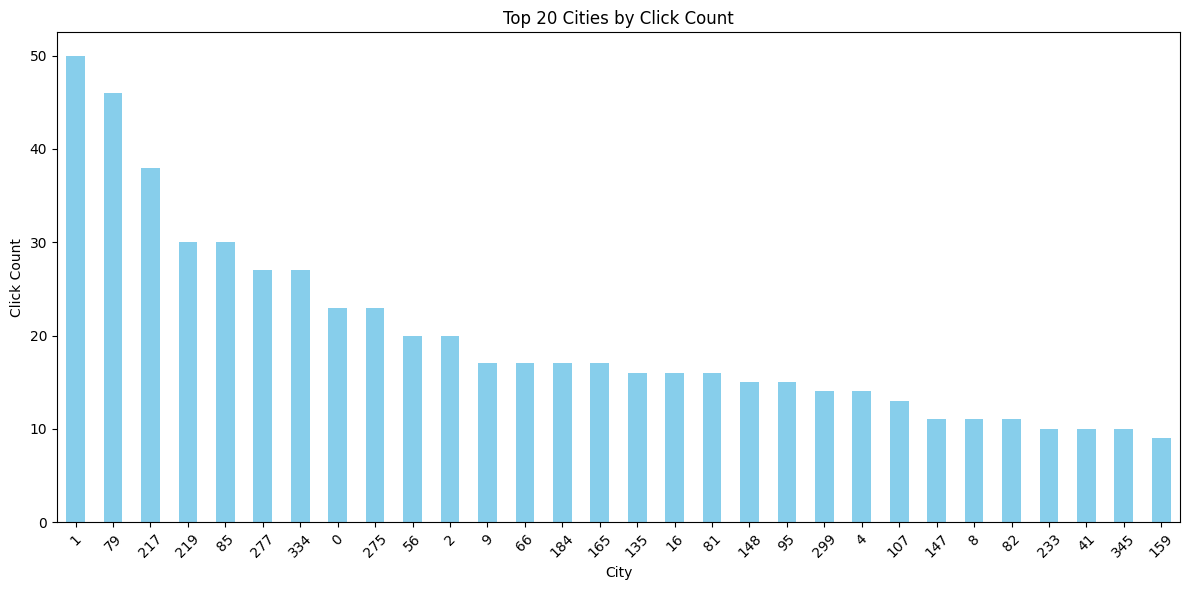

In [18]:
# 計算每個 city 的 click 總數，並排序
click_count_by_city = df.groupby('city')['click'].sum().sort_values(ascending=False)

# 取前30名城市
top20_click_cities = click_count_by_city.head(30)

# 畫長條圖
plt.figure(figsize=(12, 6))
top20_click_cities.plot(kind='bar', color='skyblue')
plt.title("Top 20 Cities by Click Count")
plt.xlabel("City")
plt.ylabel("Click Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

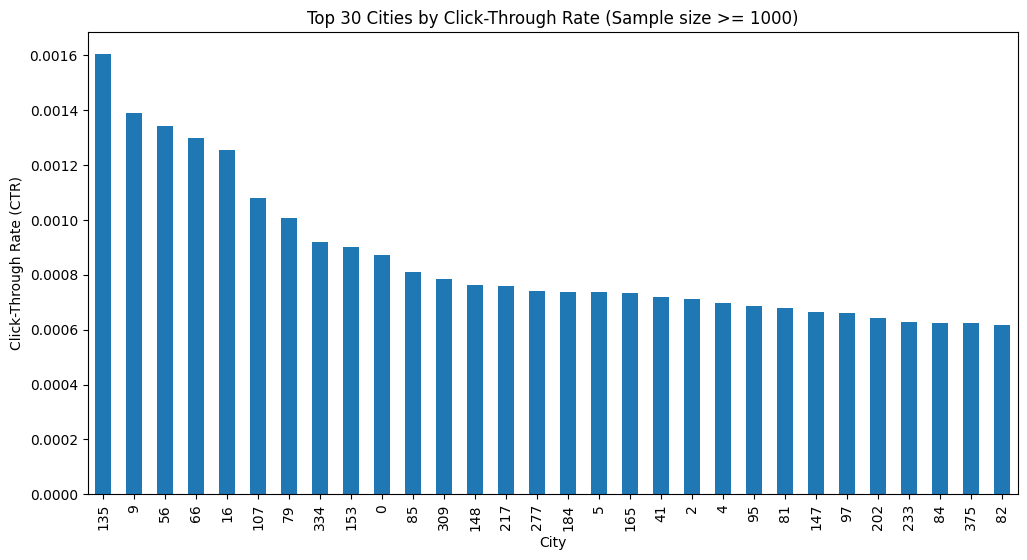

In [19]:
city_counts = df['city'].value_counts()
min_samples = 9000

# 只保留樣本數大於門檻的城市
valid_cities = city_counts[city_counts >= min_samples].index

# 計算這些城市的 CTR 並排序
ctr_filtered = df[df['city'].isin(valid_cities)].groupby('city')['click'].mean().sort_values(ascending=False)

# 畫圖
ctr_filtered.head(30).plot(kind='bar', figsize=(12,6))
plt.title("Top 30 Cities by Click-Through Rate (Sample size >= 1000)")
plt.xlabel("City")
plt.ylabel("Click-Through Rate (CTR)")
plt.show()


In [20]:
print(f'city代號232的數量:{df[df["city"] == 88].shape[0]}')

city代號232的數量:3869


region
359    0.001468
298    0.001100
134    0.001052
368    0.001024
79     0.001005
106    0.000955
344    0.000948
333    0.000930
15     0.000929
65     0.000920
Name: click, dtype: float64


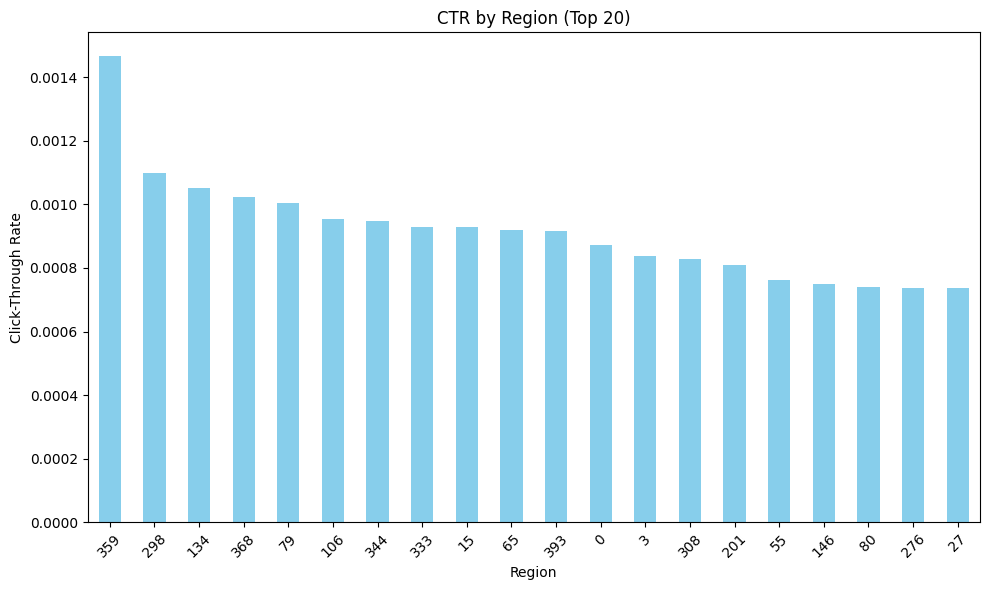

In [21]:
# 每個 region 的點擊率（CTR）
ctr_by_region = df.groupby('region')['click'].mean().sort_values(ascending=False)

# 顯示前幾個看看
print(ctr_by_region.head(10))
# 如果 region 很多，只畫 CTR 前 20 高的
ctr_by_region.head(20).plot(kind='bar', figsize=(10, 6), color='skyblue')

plt.title("CTR by Region (Top 20)")
plt.xlabel("Region")
plt.ylabel("Click-Through Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [22]:
count_359 = df[df['region'] == 359].shape[0]
print(f"region 359 的樣本數: {count_359}")

region 359 的樣本數: 5448


#### user_agent 處理

In [23]:
missing =df['user_agent'].isnull().sum()
print(f"user_agent缺失值數量: {missing}")

user_agent缺失值數量: 233


In [24]:
import re

# 假設 df['user_agent'] 已經有資料
def parse_user_agent(ua):
    if not isinstance(ua, str):
        ua = 'unknown'  
    ua = ua.lower()
    
    # 瀏覽器判斷
    if 'chrome' in ua:
        browser = 'Chrome'
        match = re.search(r'chrome/(\d+)', ua)
        version = int(match.group(1)) if match else -1
    elif 'msie' in ua or 'trident' in ua:
        browser = 'IE'
        match = re.search(r'msie (\d+)', ua)
        version = int(match.group(1)) if match else (11 if 'trident/7' in ua else -1)
    elif 'firefox' in ua:
        browser = 'Firefox'
        match = re.search(r'firefox/(\d+)', ua)
        version = int(match.group(1)) if match else -1
    elif 'safari' in ua and 'chrome' not in ua:
        browser = 'Safari'
        match = re.search(r'version/(\d+)', ua)
        version = int(match.group(1)) if match else -1
    else:
        browser = 'Other'
        version = -1
    
    # 作業系統判斷
    if 'windows nt 5.1' in ua:
        os = 'Windows XP'
    elif 'windows nt 6.1' in ua:
        os = 'Windows 7'
    elif 'android' in ua:
        os = 'Android'
    elif 'iphone' in ua or 'ipad' in ua or 'ios' in ua:
        os = 'iOS'
    elif 'windows nt 10' in ua:
        os = 'Windows 10'
    else:
        os = 'Other'

    # 是否為手機裝置
    is_mobile = int('android' in ua or 'iphone' in ua or 'ipad' in ua)

    # 是否為舊版 IE 或 Chrome < 30
    is_old_browser = int((browser == 'IE' and version <= 8) or (browser == 'Chrome' and version < 30))

    return pd.Series([browser, version, os, is_mobile, is_old_browser])

# 套用轉換
df[['browser', 'browser_version', 'os', 'is_mobile', 'is_old_browser']] = df['user_agent'].apply(parse_user_agent)
df=df.drop(columns=['user_agent'])


In [25]:
# 建立 OneHotEncoder，設定 sparse=False 直接輸出 numpy array
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 選取需要做 OneHot 的欄位
cols_to_ohe = ['browser', 'os']

# 做 fit_transform
ohe_array = ohe.fit_transform(df[cols_to_ohe])

# 轉成 DataFrame，欄位名稱會是 browser_XXX 和 os_XXX
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(cols_to_ohe), index=df.index)

# 合併回原 DataFrame
df = pd.concat([df, ohe_df], axis=1)

# 確保數值欄位型態正確
df['browser_version'] = df['browser_version'].astype(float)
df['is_mobile'] = df['is_mobile'].astype(int)
df['is_old_browser'] = df['is_old_browser'].astype(int)

# 刪除原本欄位
df = df.drop(columns=cols_to_ohe)

#### user_tags處理

In [26]:
def split_tags_to_cols(tags_str, max_tags=7):
    if not isinstance(tags_str, str) or tags_str == '':
        return [0] * max_tags
    tags = tags_str.split(',')
    # 取前 max_tags 個，長度不足補 0
    tags = tags[:max_tags] + ['0'] * (max_tags - len(tags))
    return tags

# 先把拆好的 list 變成 dataframe
tags_df = df['user_tags'].apply(split_tags_to_cols).apply(pd.Series)

# 把欄位命名成 user_tag_1, user_tag_2, ..., user_tag_7
tags_df.columns = [f'user_tag_{i+1}' for i in range(tags_df.shape[1])]
tags_df = tags_df.astype(int)  # 👈 加上這行就會變成 int

# 把新的欄位合併回原本 df
df = pd.concat([df, tags_df], axis=1)

# 刪除原本的 user_tags 欄
df = df.drop(columns=['user_tags'])

#### time_stamp處理

In [27]:
missing =df['timestamp'].isnull().sum()
print(f"timestamp缺失值數量: {missing}")

timestamp缺失值數量: 0


In [28]:
df['day'] = df['timestamp'].str[8:10].astype(int)     # 第 9～10 位是日期
df['hour'] = df['timestamp'].str[11:13].astype(int)   # 第 12～13 位是小時
df=df.drop(columns=['timestamp'])


In [29]:
for i in df.columns:
    print(f'{i  }')

ad_slot_format
click
city
ad_slot_width
ad_slot_height
region
ad_slot_floor_price
ad_exchange_1
ad_exchange_2
ad_exchange_3
ad_slot_visibility_0
ad_slot_visibility_1
ad_slot_visibility_2
ad_slot_visibility_255
creative_id_2abc9eaf57d17a96195af3f63c45dc72
creative_id_48f2e9ba15708c0146bda5e1dd653caa
creative_id_612599432d200b093719dd1f372f7a30
creative_id_77819d3e0b3467fe5c7b16d68ad923a1
creative_id_832b91d59d0cb5731431653204a76c0e
creative_id_a499988a822facd86dd0e8e4ffef8532
creative_id_cb7c76e7784031272e37af8e7e9b062c
creative_id_fb5afa9dba1274beaf3dad86baf97e89
domain_grouped_31drTvprdN1RFt
domain_grouped_31xSTvprdN1RFt
domain_grouped_3FF-e59aG5syJqKbuKz
domain_grouped_3FKElpuEMusyJqKbuKz
domain_grouped_51F-l19YBqq4gsz4JKTI
domain_grouped_5F1RQS9rg5scFsf
domain_grouped_5F97t5E0BTK7XhNrUMpENpn
domain_grouped_DDTSQuf0MTTNaqKIvMpENpn
domain_grouped_DFpETuxoGQdcFNKbuKz
domain_grouped_Dr1NTvprdN1RFt
domain_grouped_ersbQv1RdoTy1m58uG
domain_grouped_missing
domain_grouped_others
domain_grou

In [30]:
df.head(5)

,ad_slot_format,click,city,ad_slot_width,ad_slot_height,region,ad_slot_floor_price,ad_exchange_1,ad_exchange_2,ad_exchange_3,...,os_iOS,user_tag_1,user_tag_2,user_tag_3,user_tag_4,user_tag_5,user_tag_6,user_tag_7,day,hour
0,1,0,219,336,280,216,1,1.0,0.0,0.0,...,0.0,10006,10110,0,0,0,0,0,6,0
1,1,0,125,336,280,124,1,1.0,0.0,0.0,...,0.0,10031,13042,10110,0,0,0,0,6,0
2,1,0,98,336,280,94,1,1.0,0.0,0.0,...,0.0,10006,10110,0,0,0,0,0,6,0
3,1,0,1,336,280,1,1,1.0,0.0,0.0,...,0.0,10052,10006,10110,0,0,0,0,6,0
4,1,0,369,728,90,368,1,1.0,0.0,0.0,...,0.0,10074,10083,13800,10077,10006,10063,10075,6,0


#### 訓練流程

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [32]:
# 1. 建立 Dataset
class ClickDataset(Dataset):
    def __init__(self, city, region, numeric_feats, one_hot_feats, labels):
        self.city = city
        self.region = region
        self.numeric_feats = numeric_feats
        self.one_hot_feats = one_hot_feats
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {
            'city': torch.tensor(self.city[idx], dtype=torch.long),
            'region': torch.tensor(self.region[idx], dtype=torch.long),
            'numeric': torch.tensor(self.numeric_feats[idx], dtype=torch.float),
            'one_hot': torch.tensor(self.one_hot_feats[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.float),
        }
    
# 2. 定義 Model
class ClickPredictionModel(nn.Module):
    def __init__(self, num_city, num_region,numeric_dim, one_hot_dim,emb_dim=8):
        super().__init__()
        # embedding layers
        self.city_emb = nn.Embedding(num_city, emb_dim)
        self.region_emb = nn.Embedding(num_region, emb_dim)
        
        # 全連接層
        input_dim = emb_dim*2 + numeric_dim + one_hot_dim
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        
    def forward(self, city, region, numeric, one_hot):
        city_emb = self.city_emb(city)
        region_emb = self.region_emb(region)
        
        x = torch.cat([city_emb, region_emb, numeric, one_hot], dim=1)
        out = self.fc(x)
        return out.squeeze()
    
#city、region、numeric_feat、catagories數據集
city=df['city'].values.astype(np.int64)
region=df['region'].values.astype(np.int64)
scaler=StandardScaler()
numeric_scaled = scaler.fit_transform(df[['ad_slot_width','ad_slot_height','ad_slot_floor_price']])
# 轉為 numpy array 的 float32 型別（如果之後要送入 PyTorch）
numeric_feat = numeric_scaled.astype(np.float32)
#numeric_feat=df[['ad_slot_width','ad_slot_height','ad_slot_floor_price']].values.astype(np.int64)

one_hot_cols = [col for col in df.columns if col.startswith('ad_slot_format_') or 
                col.startswith('ad_exchange_') or
                col.startswith('ad_slot_visibility_') or
                col.startswith('creative_id_') or
                col.startswith('domain_grouped_') or
                col.startswith('browser_') or
                col.startswith('os_') or
                col.startswith('user_tag_')]

catagories_feat=df[one_hot_cols].values.astype(np.int64)

#city、region、numeric、catagories維度
num_city=int(df['city'].max())+1
num_region=int(df['region'].max())+1
num_numeric_feature=3
num_catagories=catagories_feat.shape[1]

#label
label=df['click'].values.astype(np.int64)

#----資料切分-----
train_idx, val_idx = train_test_split(np.arange(len(label)), test_size=0.2, stratify=label, random_state=42)

train_dataset = ClickDataset(city[train_idx], region[train_idx], numeric_feat[train_idx], catagories_feat[train_idx], label[train_idx])
val_dataset = ClickDataset(city[val_idx], region[val_idx], numeric_feat[val_idx], catagories_feat[val_idx], label[val_idx])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# --- 模型訓練 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ClickPredictionModel(num_city, num_region, numeric_dim=num_numeric_feature, one_hot_dim=num_catagories).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 加權 loss 處理不平衡
pos_weight = (len(label[train_idx]) - label[train_idx].sum()) / label[train_idx].sum()
pos_weight = torch.tensor([pos_weight]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

#-- 訓練 --
best_auc=0
for epoch in range(10):
    model.train()
    total_loss=0
    for batch in train_loader:
        city=batch['city'].to(device)
        region=batch['region'].to(device)
        numeric=batch['numeric'].to(device)
        one_hot=batch['one_hot'].to(device)
        labels=batch['label'].to(device)

        output = model(city, region, numeric, one_hot)
        loss = criterion(output, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # 驗證
    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for batch in val_loader:
            city = batch['city'].to(device)
            region = batch['region'].to(device)
            numeric = batch['numeric'].to(device)
            one_hot = batch['one_hot'].to(device)
            labels = batch['label'].to(device)

            output = model(city, region, numeric, one_hot)
            preds.extend(output.cpu().numpy())
            truths.extend(labels.cpu().numpy())

    val_auc = roc_auc_score(truths, preds)
    print(f"Epoch {epoch+1} | Train Loss: {total_loss:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), 'best_model.pth')


Epoch 1 | Train Loss: 1325272.6922 | Val AUC: 0.5076
Epoch 2 | Train Loss: 1053231.4983 | Val AUC: 0.5067


KeyboardInterrupt: 